In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os

dataset_path = "dataset/brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

print("Yes Images:", len(os.listdir(yes_path)))
print("No Images:", len(os.listdir(no_path)))

Yes Images: 155
No Images: 98


In [5]:
IMG_SIZE = 128

images = []
labels = []

for filename in os.listdir(yes_path):
    img = cv2.imread(os.path.join(yes_path, filename))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)
    labels.append(1)

for filename in os.listdir(no_path):
    img = cv2.imread(os.path.join(no_path, filename))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)
    labels.append(0)

images = np.array(images)
labels = np.array(labels)

print(images.shape)
print(labels.shape)

(253, 128, 128, 3)
(253,)


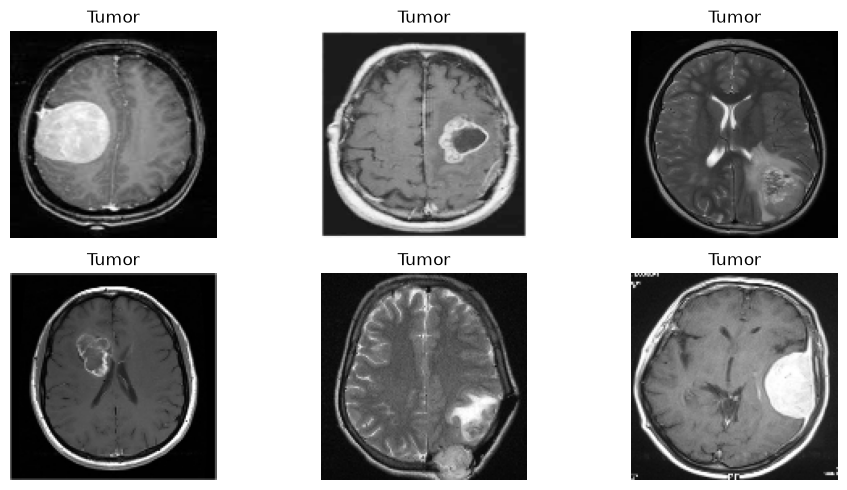

In [6]:
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Tumor" if labels[i]==1 else "No Tumor")

plt.tight_layout()
plt.show()

In [7]:
images = images.astype("float32") / 255.0

In [8]:
labels = to_categorical(labels, num_classes=2)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(X_train.shape)
print(X_test.shape)

(202, 128, 128, 3)
(51, 128, 128, 3)


In [10]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(2,activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\shris\OneDrive\Desktop\Brain-MRI-Tumor-Detection-CNN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.6273 - loss: 0.8599 - val_accuracy: 0.5854 - val_loss: 0.6390
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.6894 - loss: 0.6026 - val_accuracy: 0.4634 - val_loss: 0.7495
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.7081 - loss: 0.5663 - val_accuracy: 0.7805 - val_loss: 0.5141
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7329 - loss: 0.5277 - val_accuracy: 0.7805 - val_loss: 0.4915
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.7640 - loss: 0.5679 - val_accuracy: 0.6829 - val_loss: 0.6025
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.7702 - loss: 0.5115 - val_accuracy: 0.7561 - val_loss: 0.5583
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.8075 - loss: 0.5134 - val_accuracy: 0.7805 - val_loss: 0.5180
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.7888 - loss: 0.4577 - val_accuracy: 0.7805 - val_loss:

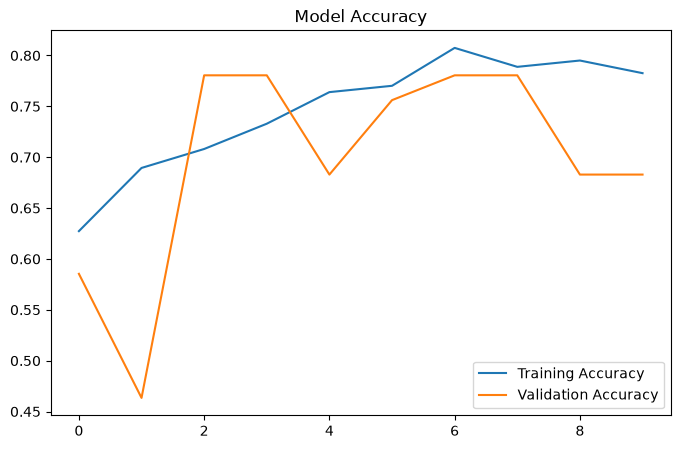

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.legend()
plt.title("Model Accuracy")
plt.show()

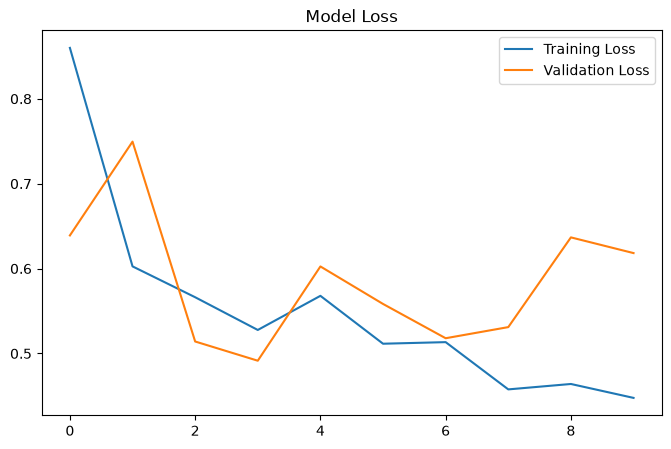

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.legend()
plt.title("Model Loss")
plt.show()

In [14]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Test Loss :",loss)
print("Test Accuracy :",accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8431 - loss: 0.3787
Test Loss : 0.37865346670150757
Test Accuracy : 0.843137264251709


In [15]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


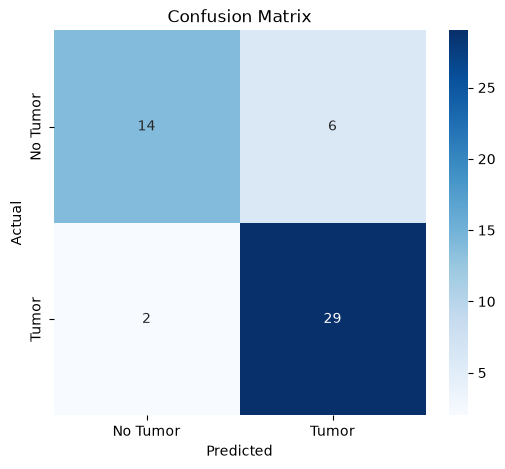

In [16]:
cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Tumor","Tumor"],
    yticklabels=["No Tumor","Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=["No Tumor","Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       0.88      0.70      0.78        20
       Tumor       0.83      0.94      0.88        31

    accuracy                           0.84        51
   macro avg       0.85      0.82      0.83        51
weighted avg       0.85      0.84      0.84        51



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction : Tumor
Actual : Tumor


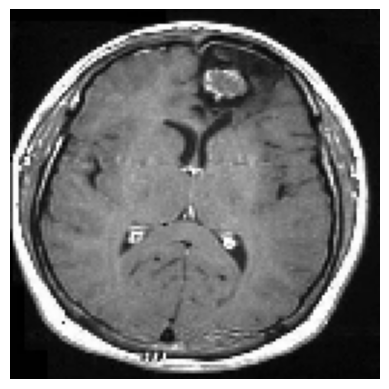

In [18]:
index = np.random.randint(0,len(X_test))

prediction = model.predict(X_test[index:index+1])

predicted = np.argmax(prediction)

plt.imshow(X_test[index])

plt.axis("off")

print("Prediction :", "Tumor" if predicted==1 else "No Tumor")
print("Actual :", "Tumor" if y_true[index]==1 else "No Tumor")

In [19]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/brain_tumor_cnn.h5")

print("Model saved successfully!")

Model saved successfully!



Conclusion

1. MRI images were successfully preprocessed.
2. A CNN model was trained to classify tumor and non-tumor MRI images.
3. The model was evaluated using test accuracy, confusion matrix, and classification report.
4. The trained model was saved for future predictions.
